In [15]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

## Exploring Data Distributions and Visual Patterns Using EDA Techniques

In [16]:

df = pd.read_csv("https://raw.githubusercontent.com/mwaskom/seaborn-data/master/tips.csv")

In [17]:
df.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


# Task - 1

### Distribution Analysis Using Histograms

In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   total_bill  244 non-null    float64
 1   tip         244 non-null    float64
 2   sex         244 non-null    object 
 3   smoker      244 non-null    object 
 4   day         244 non-null    object 
 5   time        244 non-null    object 
 6   size        244 non-null    int64  
dtypes: float64(2), int64(1), object(4)
memory usage: 13.5+ KB


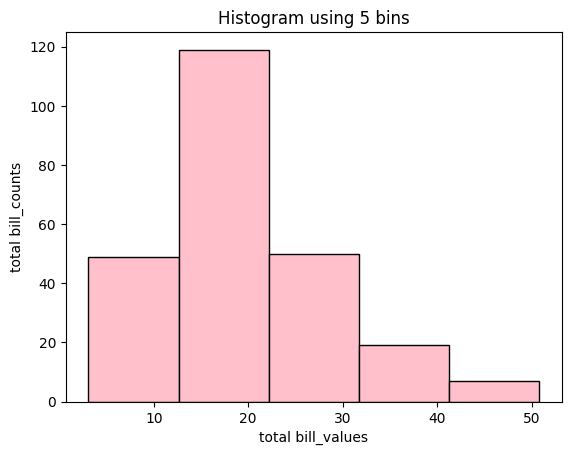

In [19]:
plt.hist(df['total_bill'],bins=5,edgecolor='black',color='pink')
plt.xlabel("total bill_values")
plt.ylabel("total bill_counts")
plt.title("Histogram using 5 bins")
plt.show()

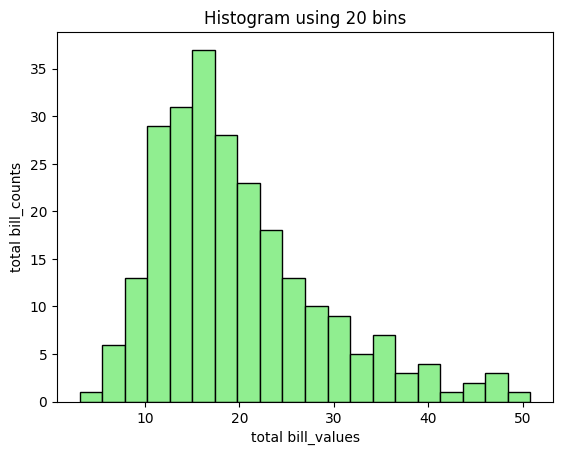

In [20]:
plt.hist(df['total_bill'],bins=20,edgecolor='black',color='lightgreen')
plt.xlabel("total bill_values")
plt.ylabel("total bill_counts")
plt.title("Histogram using 20 bins")
plt.show()

##### 1.The distribution of total_bill look like a Right skewed where all the major points are present at left side of the plot

#### 2.when the bins are less there is too much grouping occured a point, But when the bins are increased the distribution decreased and plot showed the values and counts in detail.

## Task - 2

### Outlier Detection Using Box Plots

In [21]:
df['day'].unique()

array(['Sun', 'Sat', 'Thur', 'Fri'], dtype=object)

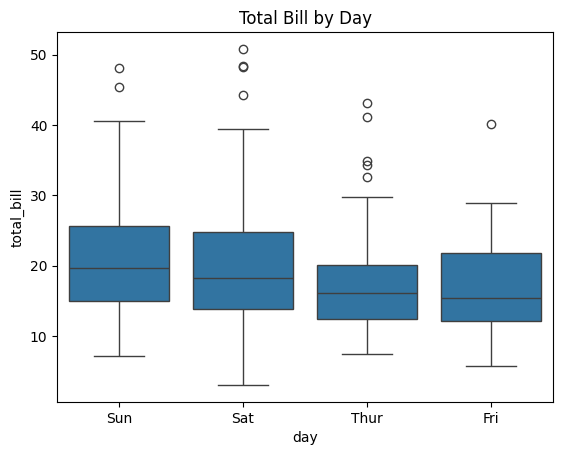

In [22]:
sns.boxplot(x=df['day'],y=df['total_bill'])
plt.title("Total Bill by Day")
plt.show()

#### 1.On sunday median total bill is heighest

In [23]:
# Calculate Q1 and Q3 per day
Q1 = df.groupby('day')['total_bill'].quantile(0.25)
Q3 = df.groupby('day')['total_bill'].quantile(0.75)

# Calculate IQR
IQR = Q3 - Q1
x  = Q1 - 1.5*IQR
x1 = Q3 - 1.5*IQR
# Combine into a DataFrame for clarity
#iqr_df = pd.DataFrame({'Q1': Q1, 'Q3': Q3, 'IQR': IQR})
#print(iqr_df)
print(x)
print(x1)

day
Fri    -2.38750
Sat    -2.34750
Sun    -0.92750
Thur    0.87375
Name: total_bill, dtype: float64
day
Fri     7.26750
Sat     8.48750
Sun     9.68250
Thur    8.58625
Name: total_bill, dtype: float64


## Task - 3

In [24]:
#this code helps to run plotly in jupyter notebook
import plotly.io as pio
pio.renderers.default = 'notebook'

In [29]:
import plotly.express as px
fig = px.scatter(df,x='total_bill',y='tip',color='time',title="Relationship Between Total Bill and Tip")
fig.show()

#### 1.If the bill is more the Tip is given more.The tip is given accourding to the bill

#### 2.No,the tip is same in the lunch time as well as in the dinner time. The color separation revel's that the people are visiting more at the time of dinner,and the tips given is same at any time 

#### 3.a point which has total_bill = 7.25 and the tip is 5.15 here he gave more tip and another point where his bill is 32.83 but he gave very less tip as 1.17.The heighest bill at lunch time is 43.11 where as at dinner it's 50.81 